# Part 1 — CPU vs GPU Training Speed (Fashion-MNIST)

We train the **same** small neural network twice — once on the **CPU**, once on the **GPU** — and time each run.
The goal is simple: see *how much faster the GPU is* for the exact same work.

We use a small 6,000-image subset so the CPU run finishes quickly.

In [ ]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# Set a random seed so results are reproducible
torch.manual_seed(42)

## Step 1 — Check the GPU
This should print `cuda`. If it prints `cpu`, turn the GPU on:
**Runtime → Change runtime type → GPU**.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {device}")

GPU available: True
Device: cuda


## Step 2 — Load the data
A 6,000-row subset of Fashion-MNIST. Each row is one image: a `label` (0–9) plus 784 pixel values.

In [ ]:
# In Colab: upload fmnist_small.csv to the session first (folder icon on the left).
df = pd.read_csv('/content/sample_data/mnist_train_small.csv')
df.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


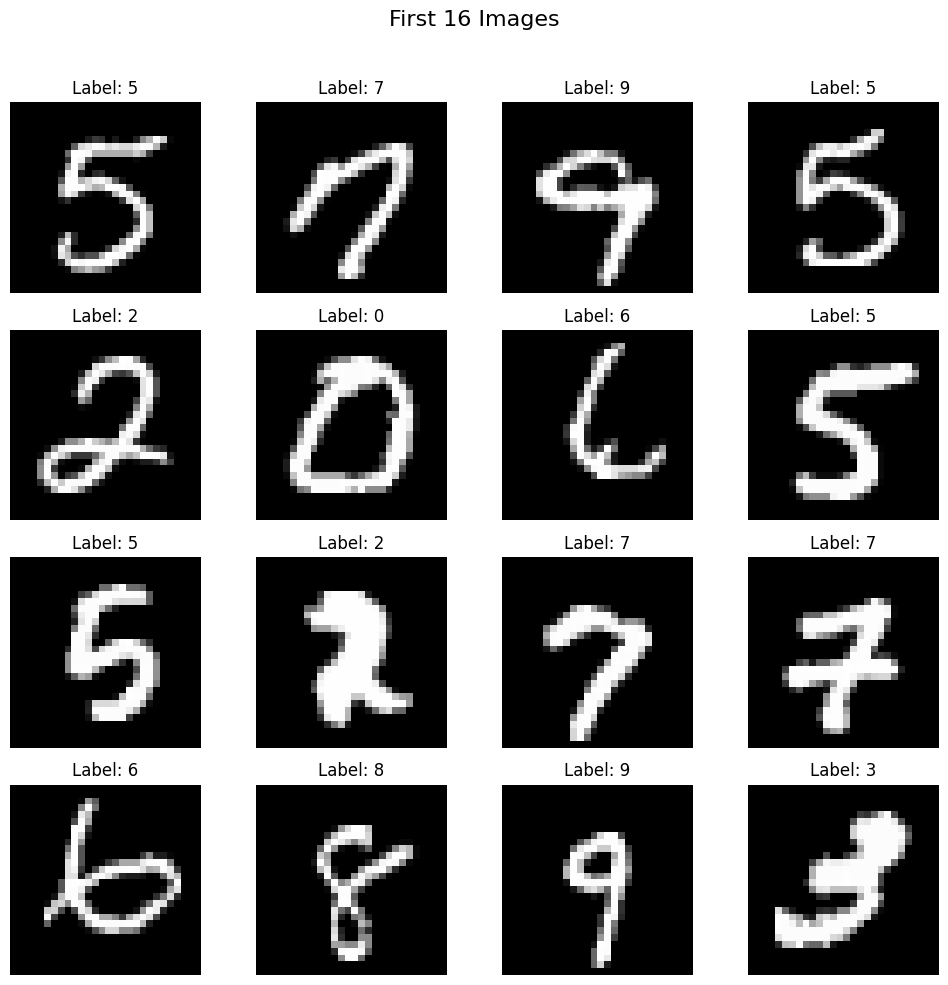

In [ ]:
# Peek at the first 16 images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Step 3 — Prepare the data
Split into train/test, scale pixels to 0–1, and wrap everything in a PyTorch `Dataset` + `DataLoader`.

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scale pixel values from 0–255 down to 0–1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

# A large batch size gives the GPU enough work per step to show its speed advantage
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

## Step 4 — Define the network
A simple fully-connected network: 784 → 128 → 64 → 10.

In [ ]:
class MyNN(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
epochs = 100
learning_rate = 0.1

## Step 5 — A function that trains *and times* the model
We put training in a function so we can call it once for the CPU and once for the GPU — same code, same starting weights, only the `device` changes.

`torch.cuda.synchronize()` makes sure we measure the GPU time correctly (GPU work runs in the background otherwise).

In [ ]:
def train_and_time(device):

    # Same starting weights every time, so the comparison is fair
    torch.manual_seed(42)
    model = MyNN(X_train.shape[1]).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    if device == 'cuda':
        torch.cuda.synchronize()
    start = time.time()

    for epoch in range(epochs):
        for batch_features, batch_labels in train_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    if device == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start

    print(f"Device: {device:4s} | final loss: {loss.item():.4f} | time: {elapsed:.2f} sec")
    return elapsed, model

## Step 6 — Train on the CPU

In [ ]:
cpu_time, cpu_model = train_and_time('cpu')

Device: cpu  | final loss: 0.0287 | time: 21.33 sec


## Step 7 — Train on the GPU

In [ ]:
gpu_time, gpu_model = train_and_time('cuda')

Device: cuda | final loss: 0.0289 | time: 14.49 sec


## Step 8 — Compare
Same network, same data, same 100 epochs — the only difference is where it ran.

CPU time: 21.33 sec
GPU time: 14.49 sec
GPU was 1.5x faster


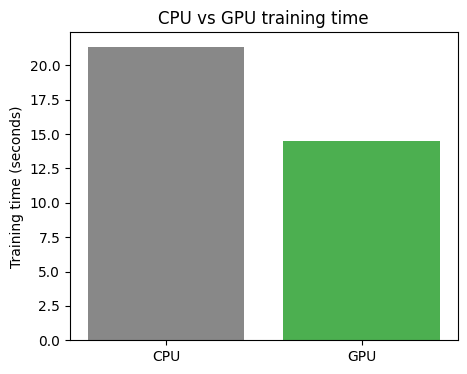

In [ ]:
print(f"CPU time: {cpu_time:.2f} sec")
print(f"GPU time: {gpu_time:.2f} sec")
print(f"GPU was {cpu_time / gpu_time:.1f}x faster")

plt.figure(figsize=(5, 4))
plt.bar(['CPU', 'GPU'], [cpu_time, gpu_time], color=['#888888', '#4caf50'])
plt.ylabel('Training time (seconds)')
plt.title('CPU vs GPU training time')
plt.show()

## Step 9 — Did it actually learn?
A quick accuracy check on the test set using the GPU-trained model.

In [ ]:
gpu_model.eval()

correct = 0
total = 0
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to('cuda')
        batch_labels = batch_labels.to('cuda')

        outputs = gpu_model(batch_features)
        _, predicted = torch.max(outputs, 1)

        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()

print(f"Test accuracy: {correct / total:.4f}")

Test accuracy: 0.9577


## Takeaway
The GPU trains the same model in a fraction of the time. On a small model like this the gap is modest, but as models and datasets grow the GPU advantage becomes huge — which is exactly why **Part 2** uses the GPU on the **full** 60,000-image dataset.